In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri Feb 20

@source: https://gitlab.com/computational-neurologie/loss-of-plasticity 
@author: yaning
"""

import sys
import json
import torch
import pickle
import numpy as np
from tqdm import tqdm
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import random_split

# from lop.algos.bp import Backprop
# from lop.algos.closs_bp import CLossBackprop
# from lop.algos.onlylyap_bp import OnlyLyapBackprop
# from lop.nets.conv_net import ConvNet
# from lop.nets.conv_net2 import ConvNet2
# from lop.algos.convCBP import ConvCBP
# from torch.nn.functional import softmax
# from lop.nets.linear import MyLinear
# from lop.utils.miscellaneous import nll_accuracy as accuracy

In [2]:
criterion = nn.CrossEntropyLoss()

In [94]:
def power_estimation(f, x, iters=100, verbose=False):
    """
    Estimate the maximum singular value of the Jacobian of function f at input x using power iteration.
    
    :param f: A function that takes input x and returns output y. The Jacobian of f at x is what we want to analyze.
    :param x: The input tensor of shape (B, d) for which we want to estimate the maximum singular value of the Jacobian of f.
    :param iters: Number of power iteration steps to perform (default: 100).
    :param verbose: If True, print intermediate results.
    """
    x = x.detach().clone().requires_grad_(True)
    x = x.unsqueeze(0)

    lambdas_list = []

    def normalize(v):
        norm = v.norm().clamp(min=1e-12)
        return v/norm
    
    
    v = torch.rand_like(x)
    v = normalize(v)

    prev_lambdas = None

    for i in range(iters):
        _, Jv = torch.autograd.functional.jvp(f, x, v)
        _, JTJv = torch.autograd.functional.vjp(f, x, v=Jv)

        v_new = JTJv
        v = normalize(v_new)

        lambdas = (v * v_new).sum()

        if verbose:
            print(f"Iter {i}: lambdas = {lambdas.tolist()}")

        if prev_lambdas is not None:
            rel = (lambdas - prev_lambdas).abs() / (prev_lambdas.abs() + 1e-12)
            if (rel < 1e-6).all():
                if verbose:
                    print("All converged.")
                break

        prev_lambdas = lambdas
        lambdas_list.append(lambdas)

        print(i)

    sv_max = torch.sqrt(torch.clamp(lambdas, min=0.0))
    # return sv_max.tolist()
    return sv_max.max(), lambdas_list

In [95]:
# weights = models.ResNet18_Weights.DEFAULT
net = models.resnet18()
net.fc = nn.Linear(net.fc.in_features, 5)

In [96]:
test = torch.rand(128, 3, 224, 224)

In [97]:
smax, lambdalist = power_estimation(net, test[0])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31


In [93]:
smax

tensor(1.6063)

In [2]:
def calc_lyapunov(model, max_singularvalue):

	scale_factor = 1/estimate_dynamical_depth(model)

	return scale_factor * (max_singularvalue+1e-9).log()

def estimate_dynamical_depth(model):
	
	model.eval()
	
	# Initialize layer count
	layer_count = 0
	
	# Iterate through all modules in the model
	for layer in model.modules():
		# Check if the layer has learnable parameters
		if len(list(layer.parameters())) > 0:
			layer_count += 1

	return layer_count
    
def calc_singularvalues(model, inputs):

	# calc jacobian
	torch.cuda.empty_cache()
	inputs = inputs.unsqueeze(0)
	jacobian_batch = torch.autograd.functional.jacobian(model, inputs, create_graph=True)

	# calc singular values
	flat_jacobian_batch = jacobian_batch.reshape(jacobian_batch.shape[0], jacobian_batch.shape[1], -1)
	svdvals = torch.linalg.svdvals(flat_jacobian_batch)

	# import pdb; pdb.set_trace()
	return svdvals



class CLossBackprop(object):
    def __init__(self, net, step_size=0.001, loss='mse', opt='sgd', beta_1=0.9, beta_2=0.999, weight_decay=0.0,
                 to_perturb=False, perturb_scale=0.1, device='cpu', momentum=0, alpha=0.1, lambda_goal=0, closs_every_N_steps=1):
        self.net = net
        self.to_perturb = to_perturb
        self.perturb_scale = perturb_scale
        self.device = device
        self.alpha = alpha
        self.lambda_goal = lambda_goal
        self.closs_every_N_steps = closs_every_N_steps

        print(f"This run uses alpha={self.alpha} and lambda_goal={self.lambda_goal} in CLoss. CLoss is applied every {closs_every_N_steps} steps.")

        # define the optimizer
        if opt == 'sgd':
            self.opt = optim.SGD(self.net.parameters(), lr=step_size, weight_decay=weight_decay, momentum=momentum)
        elif opt == 'adam':
            self.opt = optim.Adam(self.net.parameters(), lr=step_size, betas=(beta_1, beta_2),
                                  weight_decay=weight_decay)
        elif opt == 'adamW':
            self.opt = optim.AdamW(self.net.parameters(), lr=step_size, betas=(beta_1, beta_2),
                                   weight_decay=weight_decay)

        # define the loss function
        self.loss = loss
        self.loss_func = {'nll': F.cross_entropy, 'mse': F.mse_loss}[self.loss]

        # Placeholder
        self.previous_features = None
        self.singularvalues = None
        self.loss1 = None
        self.loss2 = None
        self.global_step = 0

    def learn(self, x, target):
        """
        Learn using one step of gradient-descent
        :param x: input
        :param target: desired output
        :return: loss
        """
        self.opt.zero_grad()
        # output, features = self.net.predict(x=x)
        output = self.net(x)

        crossentropy_loss = self.loss_func(output, target)
        print("this line runs")
        if self.global_step%self.closs_every_N_steps==0:
            try:
                print("this did not work?")
                singularvalues = calc_singularvalues(self.net, x[0,...]) # only calc for first sample
            except torch._C._LinAlgError:
                # import pdb; pdb.set_trace()
                singularvalues = torch.full(output[0,:][None,:].shape, torch.nan)
            lyapunov = calc_lyapunov(self.net, singularvalues.max())
            manual_scale = self.alpha
            lyapunov_loss = (self.lambda_goal-lyapunov)**2
            lyapunov_loss_scaled = lyapunov_loss * manual_scale
            # if crossentropy_loss>1e5: import pdb; pdb.set_trace()
            loss = crossentropy_loss + lyapunov_loss_scaled
            self.loss2 = lyapunov_loss_scaled.detach()
        else:
            loss = crossentropy_loss
            self.loss2 = torch.tensor(torch.nan)
        # loss = lyapunov_loss_scaled
        
        # self.previous_features = features
        # self.singularvalues = singularvalues.detach()
        self.loss1 = crossentropy_loss.detach()

        loss.backward()

        # clip gradients
        torch.nn.utils.clip_grad_norm_(self.net.parameters(), max_norm=5.0)

        self.opt.step()
        self.global_step += 1
        if self.to_perturb:
            self.perturb()
        if self.loss == 'nll':
            return loss.detach(), output.detach()
        return loss.detach()

    def perturb(self):
        with torch.no_grad():
            for i in range(int(len(self.net.layers)/2)+1):
                self.net.layers[i * 2].bias +=\
                    torch.empty(self.net.layers[i * 2].bias.shape, device=self.device).normal_(mean=0, std=self.perturb_scale)
                self.net.layers[i * 2].weight +=\
                    torch.empty(self.net.layers[i * 2].weight.shape, device=self.device).normal_(mean=0, std=self.perturb_scale)


In [3]:
class ConvNet(nn.Module):
    def __init__(self, num_classes=2):
        """
        Convolutional Neural Network with 3 convolutional layers followed by 3 fully connected layers
        """
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 5)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 128, 3)

        self.last_filter_output = 6 * 6
        self.num_conv_outputs = 128 * self.last_filter_output

        self.fc1 = nn.Linear(self.num_conv_outputs, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)
        self.pool = nn.MaxPool2d(2, 2)

        # architecture
        self.layers = nn.ModuleList()
        self.layers.append(self.conv1)
        self.layers.append(nn.ReLU())
        self.layers.append(self.conv2)
        self.layers.append(nn.ReLU())
        self.layers.append(self.conv3)
        self.layers.append(nn.ReLU())
        self.layers.append(self.fc1)
        self.layers.append(nn.ReLU())
        self.layers.append(self.fc2)
        self.layers.append(nn.ReLU())
        self.layers.append(self.fc3)

        self.act_type = 'relu'

    def predict(self, x):
        x1 = self.pool(self.layers[1](self.layers[0](x)))
        x2 = self.pool(self.layers[3](self.layers[2](x1)))
        x3 = self.pool(self.layers[5](self.layers[4](x2)))
        x3 = x3.view(-1, self.num_conv_outputs)
        x4 = self.layers[7](self.layers[6](x3))
        x5 = self.layers[9](self.layers[8](x4))
        x6 = self.layers[10](x5)
        return x6, [x1, x2, x3, x4, x5]
    
    # added this for SV calc
    def forward(self, x):
        x1 = self.pool(self.layers[1](self.layers[0](x)))
        x2 = self.pool(self.layers[3](self.layers[2](x1)))
        x3 = self.pool(self.layers[5](self.layers[4](x2)))
        x3 = x3.view(-1, self.num_conv_outputs)
        x4 = self.layers[7](self.layers[6](x3))
        x5 = self.layers[9](self.layers[8](x4))
        x6 = self.layers[10](x5)
        return x6

In [4]:
# # load dataset
# transform = transforms.Compose([
#     transforms.Resize((64, 64)),
#     transforms.ToTensor(),       
# ])

transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4,0.4,0.4,0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225])
])


train_dataset = datasets.ImageFolder(
    root="/Users/compneuro1/Downloads/tiny-imagenet-200/train",
    transform=transform
)

# num_samples = int(1 * len(train_dataset))
# indices = torch.randperm(len(train_dataset))[:num_samples]
# small_train_dataset = Subset(train_dataset, indices)

# train_loader = DataLoader(
#     small_train_dataset,
#     batch_size=64,
#     shuffle=True
# )

In [13]:
len(train_dataset)

80000

In [5]:
batch_size = 64
full_dataset = train_dataset
# ---- Split sizes ----
val_ratio = 0.2  # 20% validation
val_size = int(len(full_dataset) * val_ratio)
train_size = len(full_dataset) - val_size

# ---- Reproducibility ----
generator = torch.Generator().manual_seed(55)

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=generator
)

# ---- DataLoaders ----
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [6]:
len(train_loader)

1250

In [7]:
len(val_loader)

313

In [54]:
len(train_loader)

1250

In [8]:
test_dataset = datasets.ImageFolder(
    root="/Users/compneuro1/Downloads/tiny-imagenet-200/val",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [42]:
len(test_loader)

157

In [30]:
len(train_loader)

1563

In [9]:
net = ConvNet(num_classes=200)

In [9]:
one_batch = iter(test_loader)

In [10]:
images, labels = next(one_batch)

In [11]:
images.shape

torch.Size([64, 3, 224, 224])

In [15]:
images.max()

tensor(1.)

In [45]:
labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [10]:
output = net(images)

In [11]:
output.shape

torch.Size([64, 200])

In [13]:
torch.argmax(output, dim=1).shape

torch.Size([64])

In [12]:
a, b = output

In [23]:
pred = torch.argmax(a, dim=1)

In [28]:
pred

tensor([ 66, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115,
        115,  66, 115, 115, 115, 115,  66, 115, 115, 115, 115, 115, 115, 115,
        115, 115, 115, 115, 115, 115, 115,  66, 115, 115, 115, 115, 115, 115,
        115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115,
        115, 115, 115, 115, 115, 115, 115, 115])

In [30]:
labels.detach().cpu()

tensor([ 64, 140,  37,  52, 176,  65, 120,   8,  12,  94, 152,  32,  73, 188,
        108,  47,   2, 103, 132,  62, 162, 143, 152,  36, 126,  32,  86,  95,
        104,   2, 143, 140, 115, 129, 164, 190, 142, 154,  46,  30,  59, 166,
         65, 124,  99, 163, 118,  33,  63, 100,  34, 146,  46, 137, 135,  80,
         45, 199, 166, 130, 162, 187, 180,  90])

In [32]:
labels

tensor([ 64, 140,  37,  52, 176,  65, 120,   8,  12,  94, 152,  32,  73, 188,
        108,  47,   2, 103, 132,  62, 162, 143, 152,  36, 126,  32,  86,  95,
        104,   2, 143, 140, 115, 129, 164, 190, 142, 154,  46,  30,  59, 166,
         65, 124,  99, 163, 118,  33,  63, 100,  34, 146,  46, 137, 135,  80,
         45, 199, 166, 130, 162, 187, 180,  90])

In [24]:
confusion = torch.zeros(200, 200)
for r,p in zip(labels, pred):
    confusion[r,p] += 1

<Axes: >

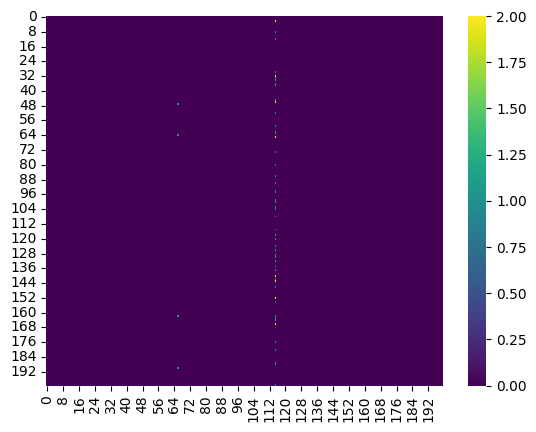

In [26]:
sns.heatmap(confusion, cmap="viridis")

In [25]:
sv = calc_singularvalues(net, images[0])
ly = calc_lyapunov(net, sv.max())

In [15]:
soft = F.softmax(a, dim=1)

In [21]:
soft[1]

tensor([0.0053, 0.0051, 0.0053, 0.0052, 0.0046, 0.0054, 0.0048, 0.0049, 0.0053,
        0.0047, 0.0053, 0.0050, 0.0045, 0.0048, 0.0047, 0.0045, 0.0047, 0.0052,
        0.0048, 0.0052, 0.0052, 0.0046, 0.0053, 0.0052, 0.0049, 0.0053, 0.0052,
        0.0050, 0.0052, 0.0049, 0.0045, 0.0053, 0.0050, 0.0053, 0.0051, 0.0053,
        0.0054, 0.0045, 0.0045, 0.0050, 0.0047, 0.0052, 0.0046, 0.0053, 0.0054,
        0.0047, 0.0052, 0.0050, 0.0051, 0.0047, 0.0051, 0.0054, 0.0050, 0.0047,
        0.0049, 0.0046, 0.0049, 0.0052, 0.0050, 0.0047, 0.0050, 0.0049, 0.0054,
        0.0046, 0.0051, 0.0051, 0.0048, 0.0049, 0.0047, 0.0050, 0.0056, 0.0051,
        0.0052, 0.0051, 0.0049, 0.0055, 0.0050, 0.0046, 0.0051, 0.0051, 0.0055,
        0.0054, 0.0053, 0.0055, 0.0053, 0.0053, 0.0049, 0.0051, 0.0050, 0.0050,
        0.0054, 0.0054, 0.0051, 0.0053, 0.0052, 0.0046, 0.0053, 0.0046, 0.0047,
        0.0049, 0.0053, 0.0047, 0.0049, 0.0049, 0.0049, 0.0049, 0.0052, 0.0052,
        0.0052, 0.0050, 0.0052, 0.0054, 

In [12]:
pred_classes = torch.argmax(a, dim=1)

In [14]:
pred_classes.shape

torch.Size([64])

In [ ]:
torch.set_printoptions(threshold=torch.inf)

In [10]:
a,b = output

In [ ]:
a.shape

torch.Size([64, 200])

In [11]:
a

tensor([[ 0.0624,  0.0261,  0.0607,  ...,  0.0147, -0.0655,  0.0223],
        [ 0.0608,  0.0256,  0.0584,  ...,  0.0186, -0.0686,  0.0210],
        [ 0.0650,  0.0260,  0.0649,  ...,  0.0183, -0.0685,  0.0234],
        ...,
        [ 0.0590,  0.0215,  0.0636,  ...,  0.0174, -0.0667,  0.0229],
        [ 0.0615,  0.0227,  0.0609,  ...,  0.0188, -0.0686,  0.0223],
        [ 0.0630,  0.0265,  0.0615,  ...,  0.0127, -0.0681,  0.0197]],
       grad_fn=<AddmmBackward0>)

In [22]:
labels

tensor([187,  35,   9,  81,  21,  48,  34,   0,  24,  99, 141,  96, 147,  10,
        153, 131,  21, 130, 106, 186, 163,  71,  27, 132,  26, 106,  58, 158,
         73, 176, 108, 191,  22, 120, 145, 103, 185, 104,  48, 101,  66,  56,
         53, 140,  17,  16,  65, 105, 110,  33, 188,  49, 151,  90,  12,  57,
        166,   1,  29, 112,  89,  75, 124, 178])

In [25]:
correct = sum(r==p for r,p in zip(labels, pred_classes))/labels.shape[0]

In [26]:
correct

tensor(0.)

In [22]:
# net = ConvNet(num_classes=200)

learner = CLossBackprop(
			net=net,
			step_size=1e-3,
			opt="sgd",
			loss='nll',
			weight_decay=0,
			to_perturb = False,
			# to_perturb=(perturb_scale != 0),
			# perturb_scale=0.01,
            # step_size=[0.01,0.001],
			device="cpu",
			momentum=0.9,
			alpha=0.1,
			lambda_goal=0.0,
			closs_every_N_steps=20
		)

This run uses alpha=0.1 and lambda_goal=0.0 in CLoss. CLoss is applied every 20 steps.


In [28]:
num_epochs = 1
losses = []
val_losses = []
num_run = 0
confusion_matrices = []

for epoch in range(num_epochs):

    total_loss = 0
    #-------------------train-------------------------------
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(learner.device), labels.to(learner.device)
        
        # if num_run % 20 == 0:
        #     learner.to_perturb = True
        # else: learner.to_perturb = False
        
        loss,_ = learner.learn(images, labels)
        losses.append(loss.item())
        total_loss += loss
        
        
        if (batch_idx + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
        num_run += 1

    #------------------validation--------------------------
    learner.net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(test_loader):
            images, labels = images.to(learner.device), labels.to(learner.device)
            predictions = learner.net(images)

            # get the loss only with cross entropy 
            # val_loss = criterion(predictions, labels)
            val_loss = learner.loss_func(predictions, labels)
            val_losses.append(val_loss.item())

            pred_classes = torch.argmax(predictions, dim=1)
            print(pred_classes.shape)
            print(labels.shape)
            # get confucion matrix
            confusion = torch.zeros(200, 200)
            for r,p in zip(labels, pred_classes):
                confusion[r,p] += 1

            correct += sum(r==p for r,p in zip(labels, pred_classes))
            total += labels.shape[0]
            print("validation accurarcy is")
            print(correct/total)
        confusion_matrices.append(confusion)


    
    print(f"Epoch [{epoch+1}/{num_epochs}] finished. Average Loss: {total_loss/len(train_loader):.4f}")

torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])
validation accurarcy is
tensor(0.)
torch.Size([64])
torch.Size([64])


KeyboardInterrupt: 

In [12]:
confusion_matrices

[]

In [22]:
val_losses

[5.408773422241211,
 5.4088263511657715,
 5.408406734466553,
 5.4084391593933105,
 5.408515453338623,
 5.4082794189453125,
 5.4087138175964355,
 5.408759117126465,
 5.408408164978027,
 5.408235549926758,
 5.408672332763672,
 5.408921718597412,
 5.40871000289917,
 5.408451080322266,
 5.408600807189941,
 5.4085693359375,
 5.408702850341797,
 5.408462047576904,
 5.40852689743042,
 5.408388614654541,
 5.408858776092529,
 5.4089179039001465,
 5.408825397491455]

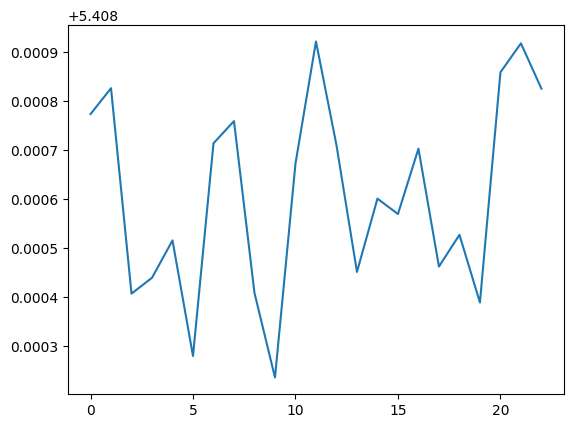

In [23]:
plt.plot(val_losses)

In [73]:
-torch.log(torch.tensor(1/200))

tensor(5.2983)